In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from helper import Autoencoder, load_data, get_embedding, format_data_into_experiment,load_params

In [2]:
# Settings for initial data
#[['OT-1'], ['A2', 'E1', 'G4', 'N4', 'Q4', 'T4', 'V4', 'null'], ['10pM', '1nM', '1uM'], ['12.0', '24.0', '30.0', '36.0', '4.0', '48.0', '60.0', '72.0']]

ignore_indexes=['Event','Replicate']

data_path = "../../initialSingleCellDf-channel-20220916-MW_018-001.h5"
data = pd.read_hdf(data_path, key="df")
data = data.loc[(data.index.get_level_values('CellType') == 'OT-1')]

strength_over_time_settings = {
    'plots_for':['CellType','Concentration'],
    'order_plots_by':[['OT-1'],['10pM', '1nM', '1uM']],
}
trajectory_graph_settings = {
    'plots_for':['CellType','Peptide'],
    'order_plots_by':[['OT-1'],['N4','A2', 'Q4', 'T4','V4', 'G4','E1','null']]
}

bar_graph_settings = {
    'color_by':'Peptide',
    'order_by':['N4','A2', 'Q4', 'T4','V4', 'G4','E1','null']
}

In [3]:
# Settings for combined data
#[['OT-1'], ['hgp100', 'mgp100', 'null'], ['N4', 'Q4', 'V4', 'null'], ['0:1', '1:0', '1:1', '1:3', '1:6', '1:9', '3:1', '9:1'], ['24.0', '36.0', '48.0', '72.0']]

# ignore_indexes=['Event']

# data_path = "../../initialSingleCellDf-channel-20220926-MW_020.h5"
# data = pd.read_hdf(data_path, key="df")
# data = data.loc[(data.index.get_level_values('CellType') == 'OT-1')]#& (data.index.get_level_values('Ratio') == '0:1')

# strength_over_time_settings = {
#     'plots_for':['CellType','Ratio'],
#     'order_plots_by':[['OT-1'],['0:1', '1:9','1:6','1:3', '1:1', '3:1', '9:1','1:0']],
# }
# trajectory_graph_settings = {
#     'plots_for':['CellType','Antigen2','Antigen1'],
#     'order_plots_by':[['OT-1'],['N4', 'Q4','V4','null'],['hgp100', 'mgp100', 'null']]
# }

# bar_graph_settings = {
#     'color_by':'Antigen2',
#     'order_by':['N4', 'Q4','V4','null']
# }

In [4]:
#load params
model_inputs,group_size,batch_size,embedding_size,autoencoder_hidden_sizes,model_path = load_params()

print("model_inputs:", model_inputs)
print("group_size:", group_size)
print("batch_size:", batch_size)
print("embedding_size:", embedding_size)
print("autoencoder_hidden_sizes:", autoencoder_hidden_sizes)
print("model_path:", model_path)

model_inputs: ['CD126', 'CD19', 'CD2', 'CD25', 'CD27', 'CD38', 'CD4', 'CD44', 'CD45', 'CD45RA', 'CD5', 'CD62L', 'CD86', 'CD8a', 'CX3CR1', 'CXCR6', 'FSC-A', 'Granzyme B', 'ICOS', 'IRF8', 'MHC-II', 'OX40', 'PD-L1', 'Proliferation', 'SSC-A', 'TBet']
group_size: 100
batch_size: 100
embedding_size: 2
autoencoder_hidden_sizes: [250, 200]
model_path: autoencoder_test.pt


In [5]:
dataset, index_order, data_index_names, data_columns, data_labels,missing_columns = load_data(data,model_inputs,ignore_indexes,group_size)
print("Missing columns: ",missing_columns)
print("Data index names: ",data_index_names)
print("Index order: ",index_order)

Missing columns:  []
Data index names:  ['CellType' 'Peptide' 'Concentration' 'Time']
Index order:  [['OT-1'], ['A2', 'E1', 'G4', 'N4', 'Q4', 'T4', 'V4', 'null'], ['10pM', '1nM', '1uM'], ['12.0', '24.0', '30.0', '36.0', '4.0', '48.0', '60.0', '72.0']]


In [6]:
model = Autoencoder(len(model_inputs),autoencoder_hidden_sizes,embedding_size)
model.load_state_dict(torch.load(model_path))
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)

In [7]:
data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [8]:
embeddings,labels,markers,strengths = get_embedding(model,data_loader,device)
print(embeddings.shape)

(61035, 2)


In [9]:
output = format_data_into_experiment(embeddings,data_labels,data_index_names,strengths,ignore_columns=[])

In [10]:
def get_graph_data(plots_for,order_plots_by,output):
    graph_titles = [[]]
    for i in range(len(plots_for)):
        new_titles = []
        for title in graph_titles:
            for label in order_plots_by[i]:
                new_titles.append(title + [label])
        graph_titles = new_titles

    all_labels = np.array([exper['label'] for exper in output])
    plots_for_indexes = [list(data_index_names).index(plot_for) for plot_for in plots_for]
    all_labels = all_labels[:,plots_for_indexes]
    graph_titles = [title for title in graph_titles if np.any(np.all(all_labels == title,axis=1))]
    graph_experiments = []
    graph_labels= []
    for title in graph_titles:
        graph_experiments.append([exper for exper in output if np.all(exper['label'][plots_for_indexes] == title)])
        graph_labels_expr= []
        for exper in graph_experiments[-1]:
            graph_labels_expr.append(' '.join(exper['label'][[i for i in range(len(exper['label'])) if i not in plots_for_indexes]]))
        graph_labels.append(graph_labels_expr)
    return graph_titles,graph_experiments,graph_labels

def get_graphs(title,output,plots_for,order_plots_by,get_plot):
    graph_titles,graph_experiments,graph_labels = get_graph_data(plots_for,order_plots_by,output)
    num_columns = min(4,len(graph_titles))
    num_rows = int((len(graph_titles)+num_columns-1)/num_columns)
    plt.figure(figsize=(5*num_columns,5*num_rows))
    plt.suptitle(title+' for each ' + ' and '.join(plots_for))
    for i,title in enumerate(graph_titles):
        plt.subplot(num_rows,num_columns,i+1)
        ax = plt.gca()
        plt.title(' '.join(title))
        for j,exper in enumerate(graph_experiments[i]):
            get_plot(exper,graph_labels[i][j],ax)
        plt.legend()
    plt.show()
def get_markers_embedding(title,embeddings,markers,feature_names,strengths,times):
    plt.figure(figsize=(20,15))
    plt.suptitle(title)
    for i in range(len(feature_names)):
        plt.subplot(5,6,i+1)
        plt.scatter(embeddings[:,0],embeddings[:,1],c=markers[:,i])
        plt.title(feature_names[i])
        plt.colorbar()
    plt.subplot(5,6,len(feature_names)+1)
    plt.scatter(embeddings[:,0],embeddings[:,1],c=strengths)
    plt.title("Strength")
    plt.colorbar()
    plt.subplot(5,6,len(feature_names)+2)
    plt.scatter(embeddings[:,0],embeddings[:,1],c=times)
    plt.title("Time")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

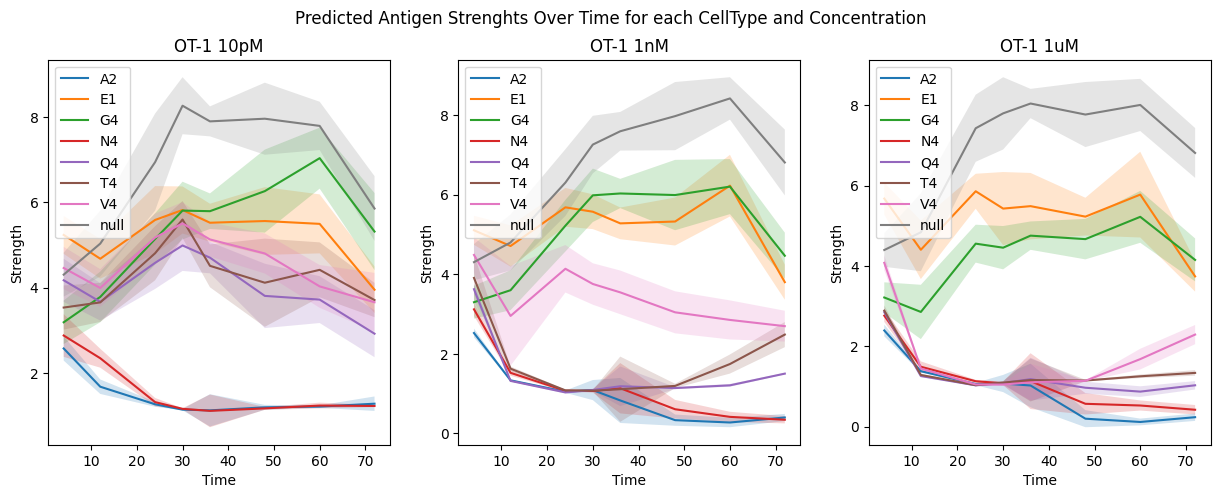

In [11]:
def get_strength_over_time_plot(exper,label,ax):
    plt.plot(exper['times'], exper['strengths'], label=label)
    plt.fill_between(exper['times'], exper['strengths']-exper['strengths_std'], exper['strengths']+exper['strengths_std'], alpha=0.2)
    plt.xlabel('Time')
    plt.ylabel('Strength')

get_graphs('Predicted Antigen Strenghts Over Time',output,strength_over_time_settings['plots_for'],strength_over_time_settings['order_plots_by'],get_strength_over_time_plot)

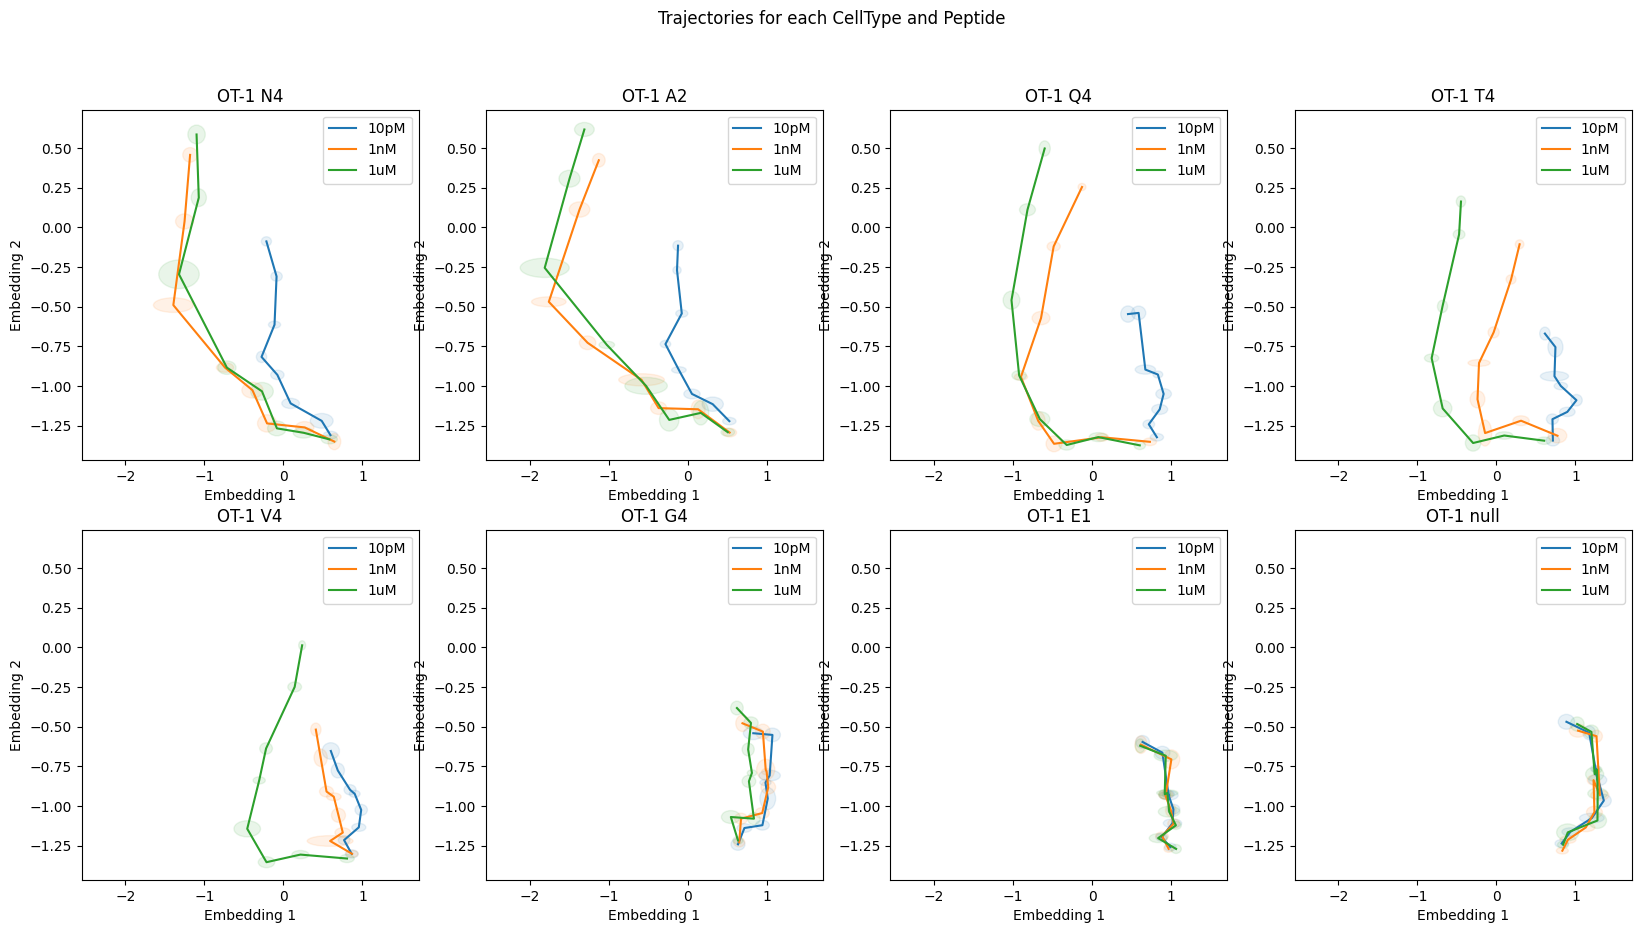

In [12]:
min_embedding_x = np.min(embeddings[:,0])
max_embedding_x = np.max(embeddings[:,0])
min_embedding_y = np.min(embeddings[:,1])
max_embedding_y = np.max(embeddings[:,1])
def get_plot(exper,label,ax):
    plt.plot(exper['embeddings'][:,0],exper['embeddings'][:,1],label=label)
    for i in range(len(exper['embeddings'])):
        ellipse = matplotlib.patches.Ellipse((exper['embeddings'][i,0], exper['embeddings'][i,1]), width=2*exper['embeddings_std'][i,0], height=2*exper['embeddings_std'][i,1], angle=0, color=ax.get_lines()[-1].get_color(), alpha=0.1)
        ax.add_patch(ellipse)
    plt.xlabel('Embedding 1')
    plt.ylabel('Embedding 2')
    plt.xlim(min_embedding_x,max_embedding_x)
    plt.ylim(min_embedding_y,max_embedding_y)
get_graphs('Trajectories',output,trajectory_graph_settings['plots_for'],trajectory_graph_settings['order_plots_by'],get_plot)

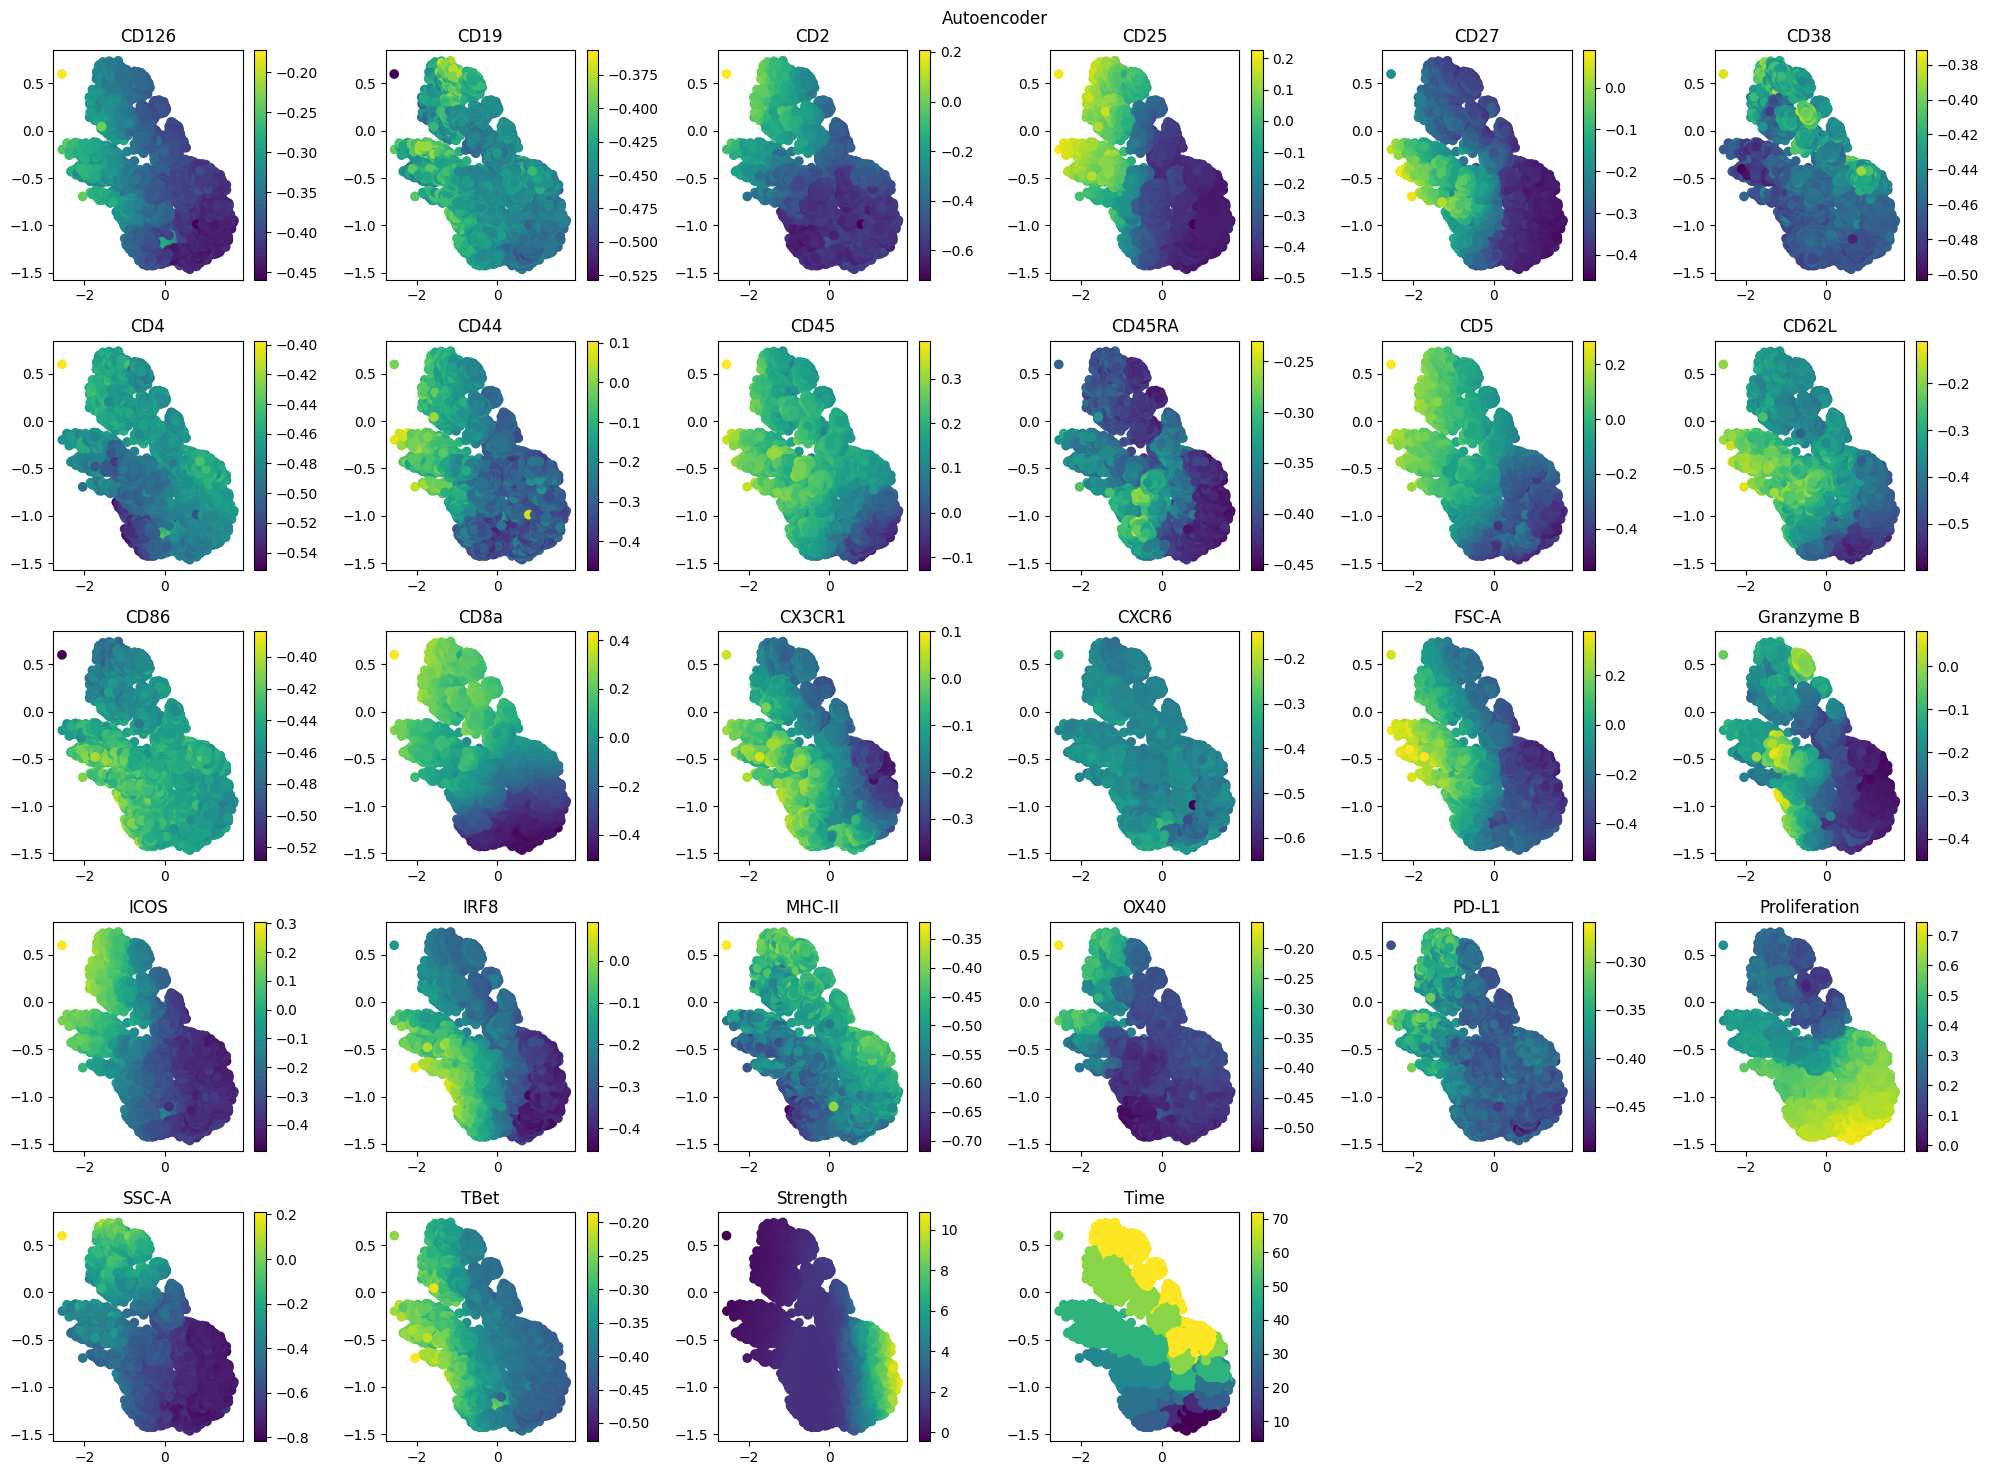

In [13]:
get_markers_embedding("Autoencoder",embeddings,markers,model_inputs,strengths,[float(d) for d in data_labels[:,list(data_index_names).index('Time')]])

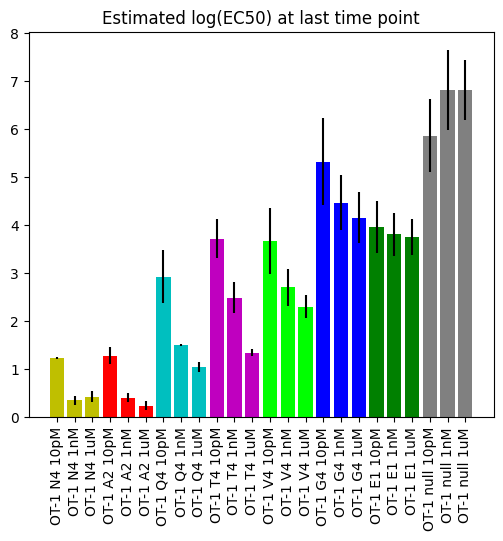

In [14]:

fig, ax = plt.subplots(figsize=(int(len(output)/4), 5))  # Set the figsize to (12, 6) for a wider plot

color_field = list(data_index_names).index(bar_graph_settings['color_by'])
colors = ['r', 'g', 'b', 'y', 'c', 'm', 'lime', 'gray', 'orange', 'purple', 'pink', 'brown', 'olive', 'cyan', 'lightblue', 'lightgreen', 'lightgrey', 'lightcoral', 'lightpink', 'lightyellow', 'lightpurple', 'lightbrown', 'lightorange', 'lightcyan', 'lightolive']
sorted_output = sorted(output, key=lambda x: bar_graph_settings['order_by'].index(x['label'][color_field]))

for exper in sorted_output:
    label = ' '.join(exper['label'])
    color_index = index_order[color_field].index(exper['label'][color_field])
    # color = get_experiment_color(experiment['label'],data_index_names)
    ax.bar(label, exper['strengths'][-1], yerr=exper['strengths_std'][-1], label=label, color=colors[color_index])
    plt.xticks(rotation=90)
plt.title("Estimated log(EC50) at last time point")
plt.show()
